In [1]:
# src/ on the path - cwd is notebooks/
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

In [2]:
# allows change in src/ to be reflected in notebook without restarting kernel
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [4]:
import prepare

canopy, landcover = prepare.align_labels()

canopy fraction: 0.268


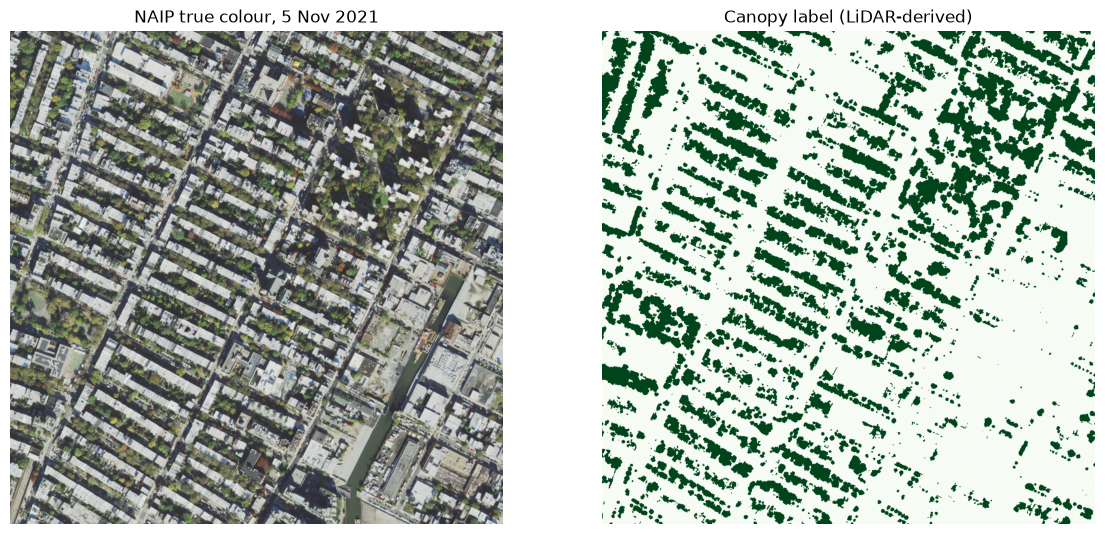

In [5]:
with rasterio.open(config.NAIP) as naip:
    rgb = naip.read([1, 2, 3], window=config.AOI)[:, :1500, :1500]

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(np.transpose(rgb, (1, 2, 0)))   # rasterio is (band, row, col)
ax[0].set_title("NAIP true colour, 5 Nov 2021")
ax[1].imshow(canopy[:1500, :1500], cmap="Greens")
ax[1].set_title("Canopy label (LiDAR-derived)")
for a in ax:
    a.axis("off")

plt.savefig(config.FIGURES / "01_alignment_check.png", dpi=120, bbox_inches="tight")
plt.show()

Alignment check shows chip of same size and resolution from both NAIP imagery and Canopy Land Cover labels. Note the subset of orange crowns in the NAIP imagery taken in November. The labeled land cover should show this as canopy regarless of foliage color as the layer is LiDAR derived and not impacted by NDVI.

In [6]:
prepare.cut_chips(landcover)

1024 chips written, 0 skipped
